# Données climatiques (NASA POWER)

`Climate` interroge l'API **NASA POWER** (https://power.larc.nasa.gov/) —
séries météo mondiales issues de ré-analyses (MERRA-2) et de produits
satellite, **sans clé API**.

- `get_point(lon, lat, start, end, ...)` → `DataFrame` indexé par date
- `get_region(bbox, start, end, ...)` → `GeoDataFrame` (grille ~0,5°, format long)

Options communes : `temporal` = `daily` (défaut) / `monthly` / `climatology`,
`community` = `ag` (agro) / `sb` (bâtiment) / `re` (renouvelable),
`parameters` = codes POWER (`T2M`, `PRECTOTCORR`, `RH2M`, `WS2M`,
`ALLSKY_SFC_SW_DWN`…). Liste : https://power.larc.nasa.gov/parameters/

In [1]:
import logging
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))  # cartograpy est à la racine du dépôt
logging.basicConfig(level=logging.INFO, format="%(message)s")

import matplotlib.pyplot as plt
import cartograpy as cp
from cartograpy.data import Climate, Bound

clim = Climate()

C:\Users\Ordinateur\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\Lib\importlib\metadata\__init__.py:467: DeprecationWarning: Implicit None on return values is deprecated and will raise KeyErrors.
  return self.metadata['Version']


## Série journalière en un point

Sans `parameters`, `Climate` renvoie un jeu par défaut (températures, rosée,
précipitations, vent, rayonnement, humidité). Les valeurs manquantes (-999)
sont mises à `NaN`.

In [2]:
abidjan = clim.get_point(-3.99, 5.35, "2023-01-01", "2023-12-31")
print(abidjan.columns.tolist())
abidjan[["T2M", "T2M_MIN", "T2M_MAX", "PRECTOTCORR", "RH2M"]].describe().round(1)

NASA POWER: https://power.larc.nasa.gov/api/temporal/daily/point


['T2M', 'T2M_MIN', 'T2M_MAX', 'T2MDEW', 'PRECTOTCORR', 'WS2M', 'ALLSKY_SFC_SW_DWN', 'RH2M']


,T2M,T2M_MIN,T2M_MAX,PRECTOTCORR,RH2M
count,365.0,365.0,365.0,365.0,365.0
mean,26.4,24.2,29.3,5.9,85.8
std,0.9,1.0,1.4,7.6,5.6
min,24.0,18.7,25.6,0.0,63.8
25%,25.6,23.7,28.3,1.0,83.8
50%,26.5,24.4,29.2,3.7,87.3
75%,27.1,24.9,30.2,7.4,89.8
max,28.6,26.0,33.6,70.1,94.0


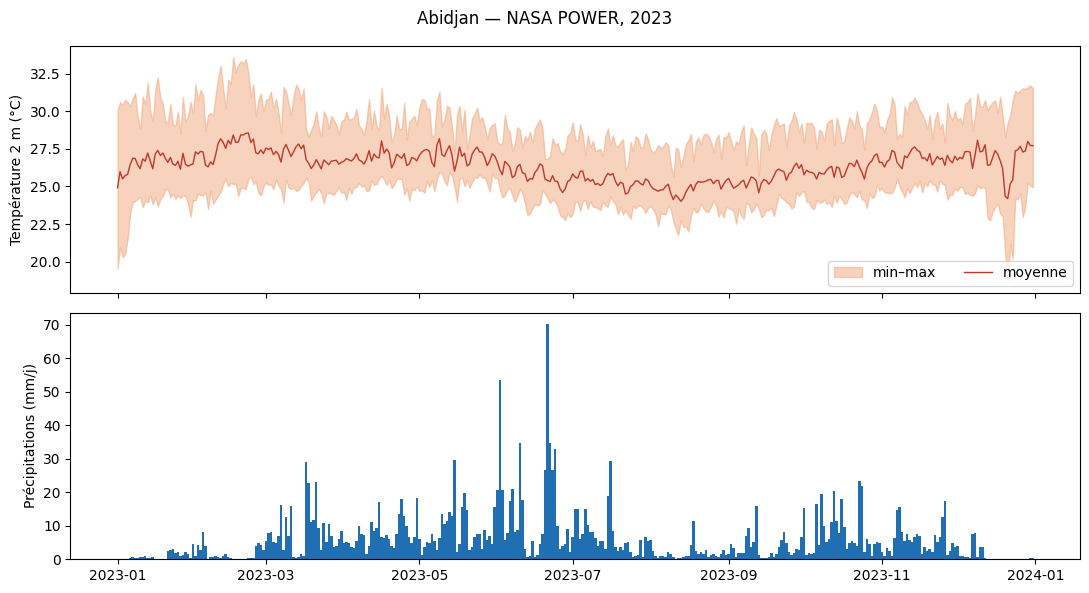

In [3]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

ax1.fill_between(abidjan.index, abidjan["T2M_MIN"], abidjan["T2M_MAX"],
                 color="#f0a67a", alpha=0.5, label="min–max")
ax1.plot(abidjan.index, abidjan["T2M"], color="#c0392b", lw=1, label="moyenne")
ax1.set_ylabel("Température 2 m (°C)")
ax1.legend(loc="lower right", ncol=2)

ax2.bar(abidjan.index, abidjan["PRECTOTCORR"], color="#1f6fb2", width=1)
ax2.set_ylabel("Précipitations (mm/j)")
fig.suptitle("Abidjan — NASA POWER, 2023")
fig.tight_layout()

## Choisir les paramètres et comparer deux sites

Abidjan (littoral, sud humide) vs Korhogo (nord, savane soudanienne).

In [4]:
params = ["T2M", "PRECTOTCORR", "RH2M"]
sites = {"Abidjan": (-3.99, 5.35), "Korhogo": (-5.63, 9.46)}

resume = {}
for nom, (lon, lat) in sites.items():
    d = clim.get_point(lon, lat, "2023-01-01", "2023-12-31", parameters=params)
    resume[nom] = {
        "T2M moy (°C)": d["T2M"].mean(),
        "Pluie totale (mm)": d["PRECTOTCORR"].sum(),
        "Humidité moy (%)": d["RH2M"].mean(),
    }

import pandas as pd
pd.DataFrame(resume).T.round(1)

NASA POWER: https://power.larc.nasa.gov/api/temporal/daily/point


NASA POWER: https://power.larc.nasa.gov/api/temporal/daily/point


,T2M moy (°C),Pluie totale (mm),Humidité moy (%)
Abidjan,26.4,2145.2,85.8
Korhogo,27.4,884.9,62.5


## Agrégation mensuelle → diagramme ombrothermique

Avec `temporal="monthly"`, `start`/`end` sont des **années**.

NASA POWER: https://power.larc.nasa.gov/api/temporal/monthly/point


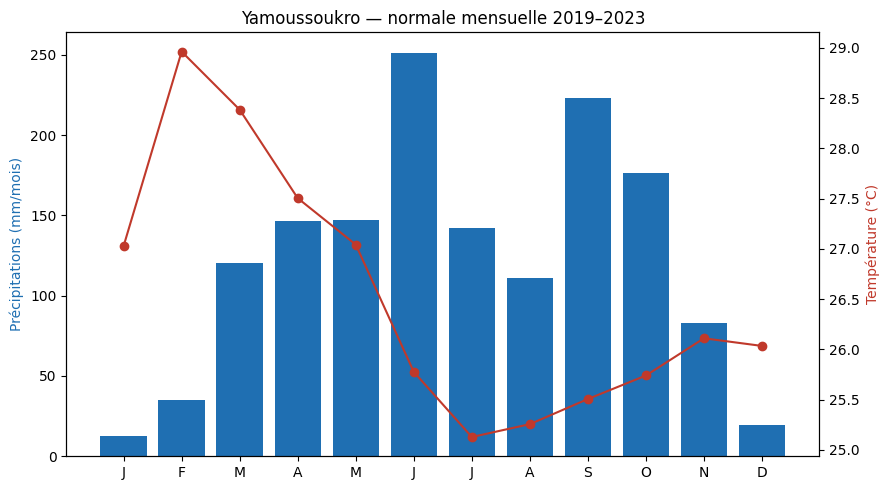

In [5]:
mens = clim.get_point(-5.27, 6.82, 2019, 2023, temporal="monthly",
                      parameters=["T2M", "PRECTOTCORR"])

# moyenne inter-annuelle par mois (PRECTOTCORR mensuel = mm/jour → ×30 ≈ mm/mois)
clim_mens = mens.groupby(mens.index.month).mean()
clim_mens["pluie_mm"] = clim_mens["PRECTOTCORR"] * 30
mois = ["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"]

fig, ax_p = plt.subplots(figsize=(9, 5))
ax_p.bar(clim_mens.index, clim_mens["pluie_mm"], color="#1f6fb2", label="Précipitations")
ax_p.set_ylabel("Précipitations (mm/mois)", color="#1f6fb2")
ax_p.set_xticks(range(1, 13)); ax_p.set_xticklabels(mois)

ax_t = ax_p.twinx()
ax_t.plot(clim_mens.index, clim_mens["T2M"], color="#c0392b", marker="o", label="Température")
ax_t.set_ylabel("Température (°C)", color="#c0392b")
ax_p.set_title("Yamoussoukro — normale mensuelle 2019–2023")
fig.tight_layout()

## Climatologie (normales longues)

`temporal="climatology"` renvoie une valeur par mois (`JAN`…`DEC`) plus la
moyenne annuelle (`ANN`), calculée sur la période demandée.

In [6]:
normales = clim.get_point(-5.27, 6.82, 2001, 2020, temporal="climatology",
                          parameters=["T2M", "PRECTOTCORR", "ALLSKY_SFC_SW_DWN"])
normales.round(2)

NASA POWER: https://power.larc.nasa.gov/api/temporal/climatology/point


,ALLSKY_SFC_SW_DWN,PRECTOTCORR,T2M
date,,,
JAN,17.38,0.44,27.44
FEB,17.37,1.86,28.75
MAR,18.62,3.28,28.21
APR,19.07,4.15,27.62
MAY,17.99,4.81,26.85
JUN,15.41,6.58,25.57
JUL,14.44,3.85,24.95
AUG,13.97,2.92,25.42
SEP,15.05,4.71,25.74


## Grille sur une emprise → carte

`get_region` renvoie un `GeoDataFrame` **long** (`parameter`, `date`,
`value`, `geometry`). L'API régionale mensuelle n'accepte **qu'un paramètre
par requête** : on boucle et on concatène (le format long s'empile
naturellement). On pivote ensuite et on agrège par point pour cartographier.

In [7]:
import geopandas as gpd
import pandas as pd

BBOX = (-8.0, 4.5, -3.0, 10.5)
parts = [
    clim.get_region(BBOX, 2023, 2023, temporal="monthly", parameters=[p])
    for p in ("T2M", "PRECTOTCORR")
]
grille = gpd.GeoDataFrame(pd.concat(parts, ignore_index=True), crs="EPSG:4326")
grille["lon"] = grille.geometry.x
grille["lat"] = grille.geometry.y

large = (grille.pivot_table(index=["lon", "lat"], columns="parameter",
                            values="value", aggfunc="mean")
         .reset_index())
pts = gpd.GeoDataFrame(large, geometry=gpd.points_from_xy(large["lon"], large["lat"]),
                       crs="EPSG:4326")
print(len(pts), "points de grille")
pts.head()

NASA POWER: https://power.larc.nasa.gov/api/temporal/monthly/regional


NASA POWER: https://power.larc.nasa.gov/api/temporal/monthly/regional


104 points de grille


parameter,lon,lat,PRECTOTCORR,T2M,geometry
0,-7.5,4.5,6.586667,26.385,POINT (-7.5 4.5)
1,-7.5,5.0,6.54,25.583333,POINT (-7.5 5)
2,-7.5,5.5,5.601667,25.34,POINT (-7.5 5.5)
3,-7.5,6.0,4.810833,25.2875,POINT (-7.5 6)
4,-7.5,6.5,4.53,25.259167,POINT (-7.5 6.5)


📊 Centrage intelligent appliqué:


   Format: Personnalisé (N/A)


   Ratio figure: 1.50


   Ratio données: 0.96


   Étendue: [-11.02, -0.11, 3.90, 11.17]


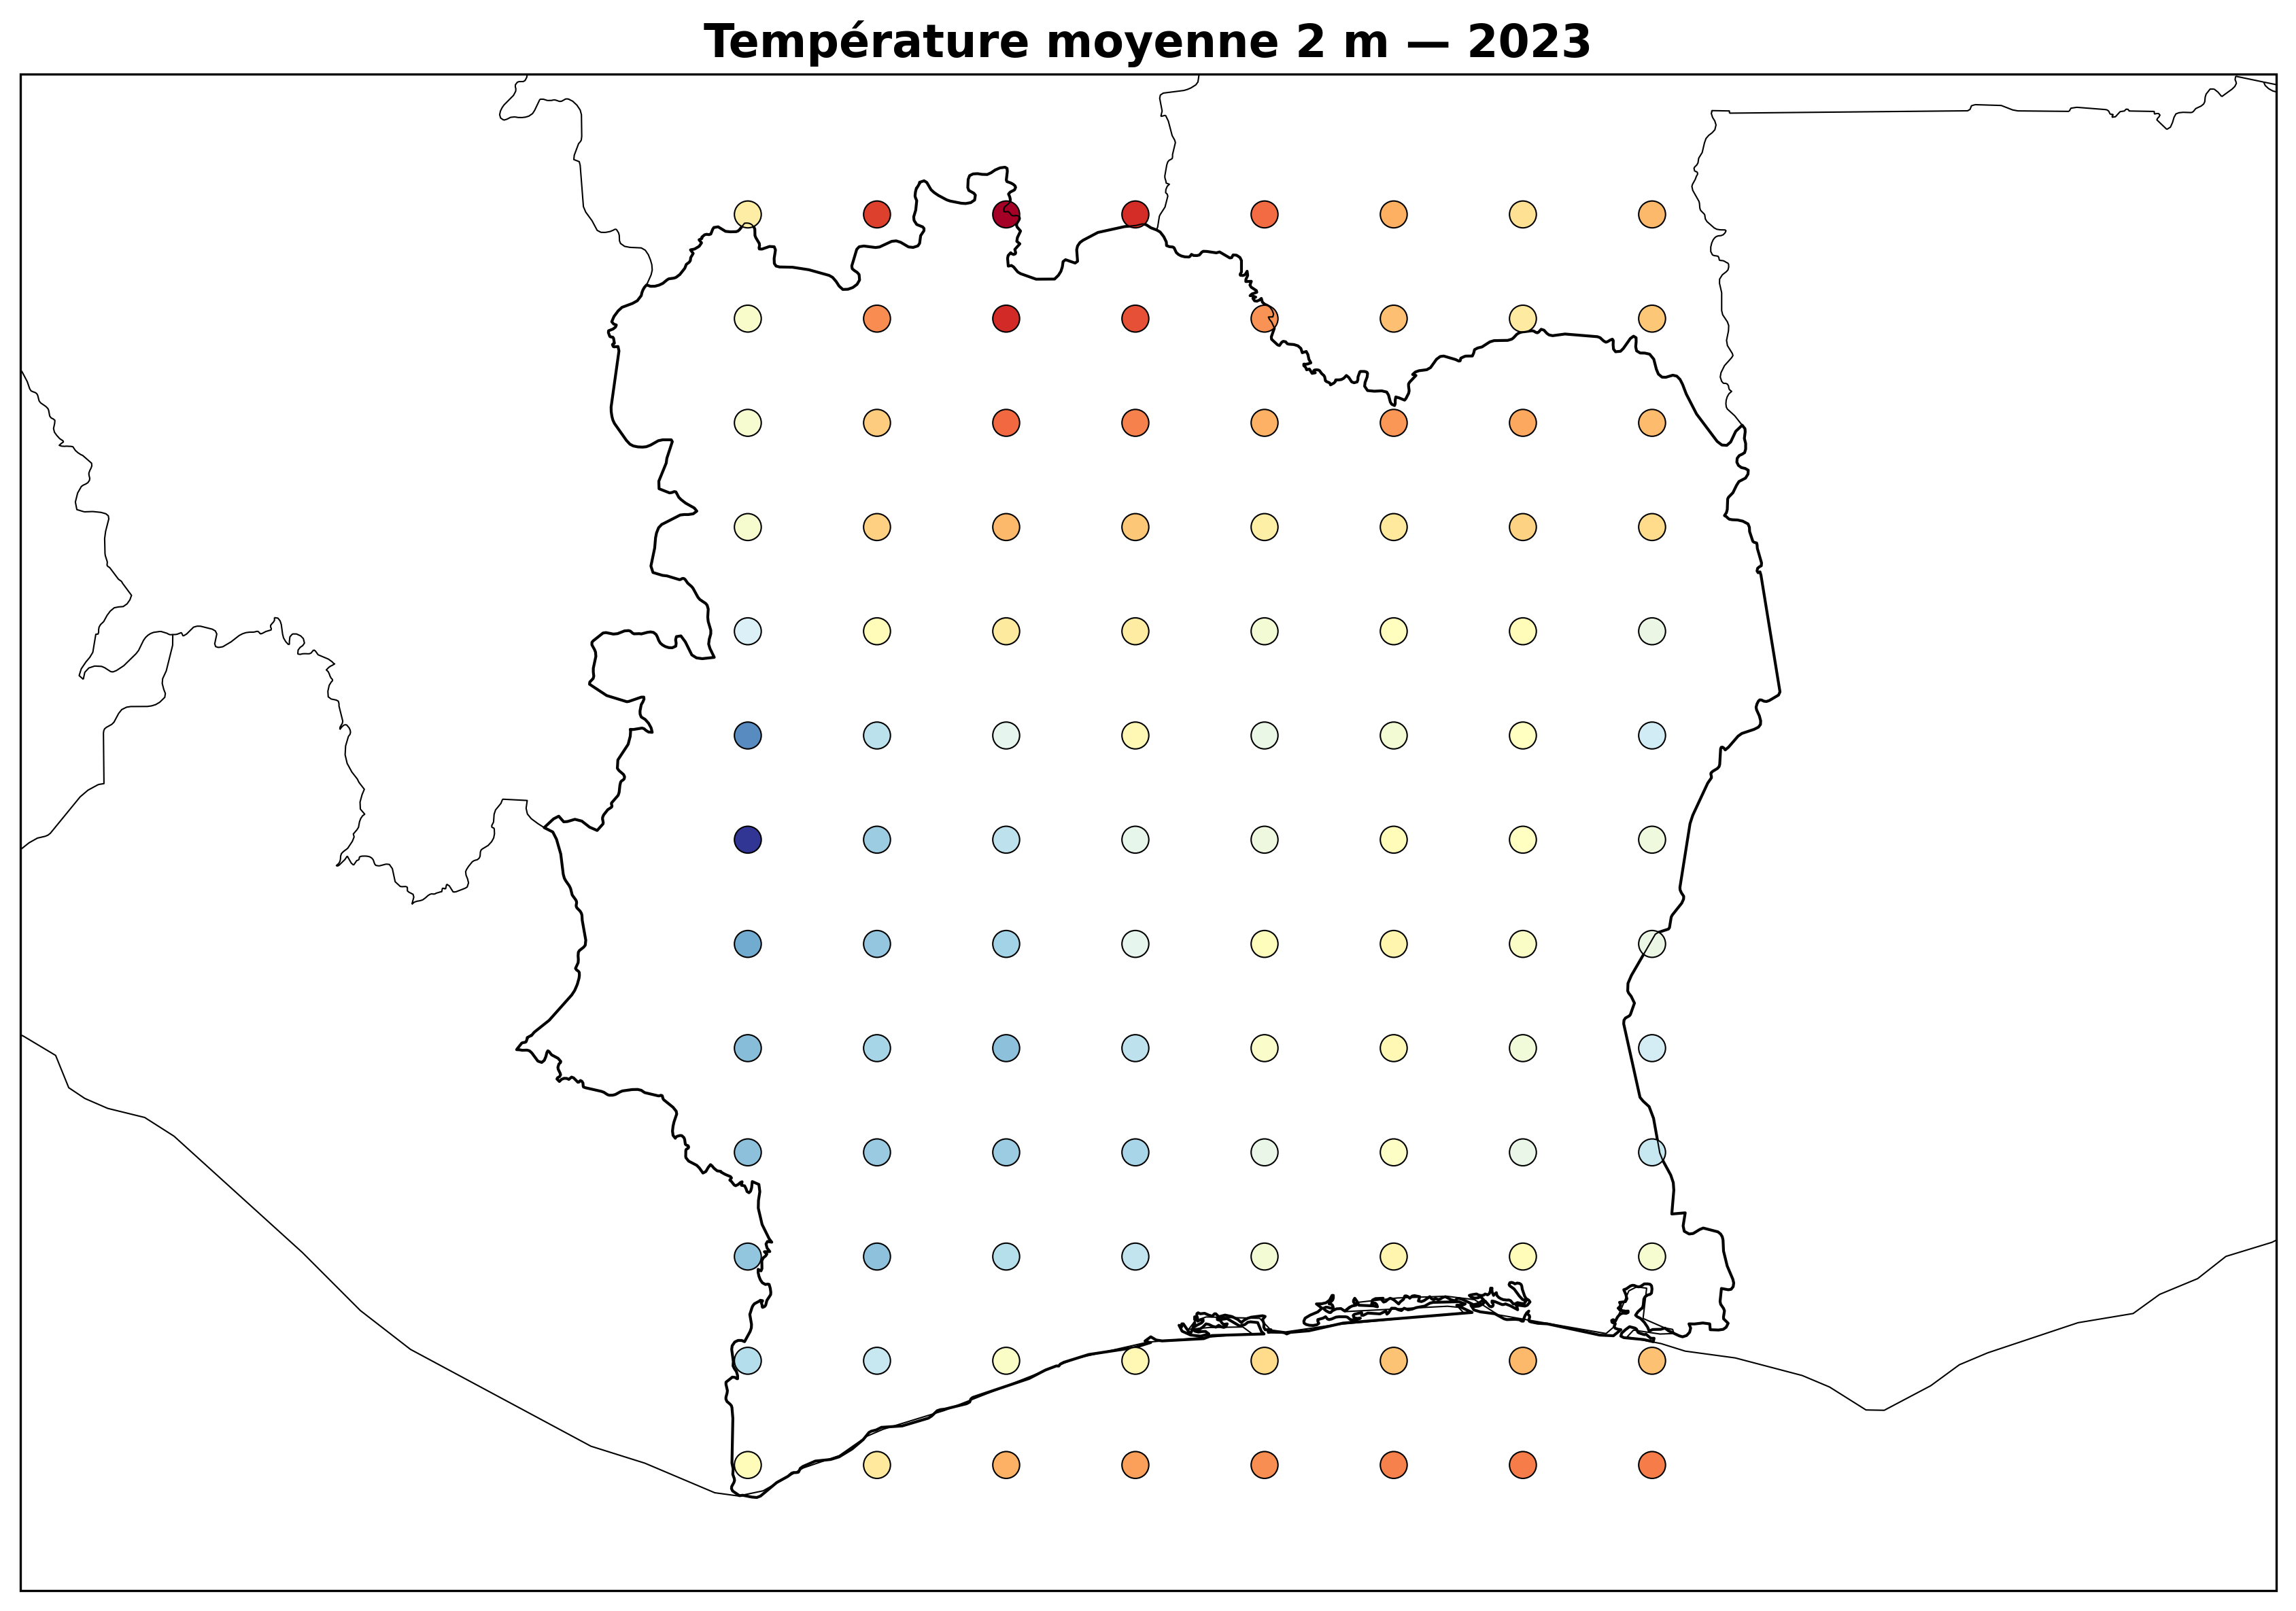

In [8]:
civ = Bound().get_country("CIV").set_crs("EPSG:4326")

m = cp.Map(title="Température moyenne 2 m — 2023")
m.add_polygons(civ, facecolor="none", edge_color="black", linewidth=1, alpha=1)
m.add_points(pts, column="T2M", cmap="RdYlBu_r", size=90)
m.show()

📊 Centrage intelligent appliqué:


   Format: Personnalisé (N/A)


   Ratio figure: 1.50


   Ratio données: 0.96


   Étendue: [-11.02, -0.11, 3.90, 11.17]


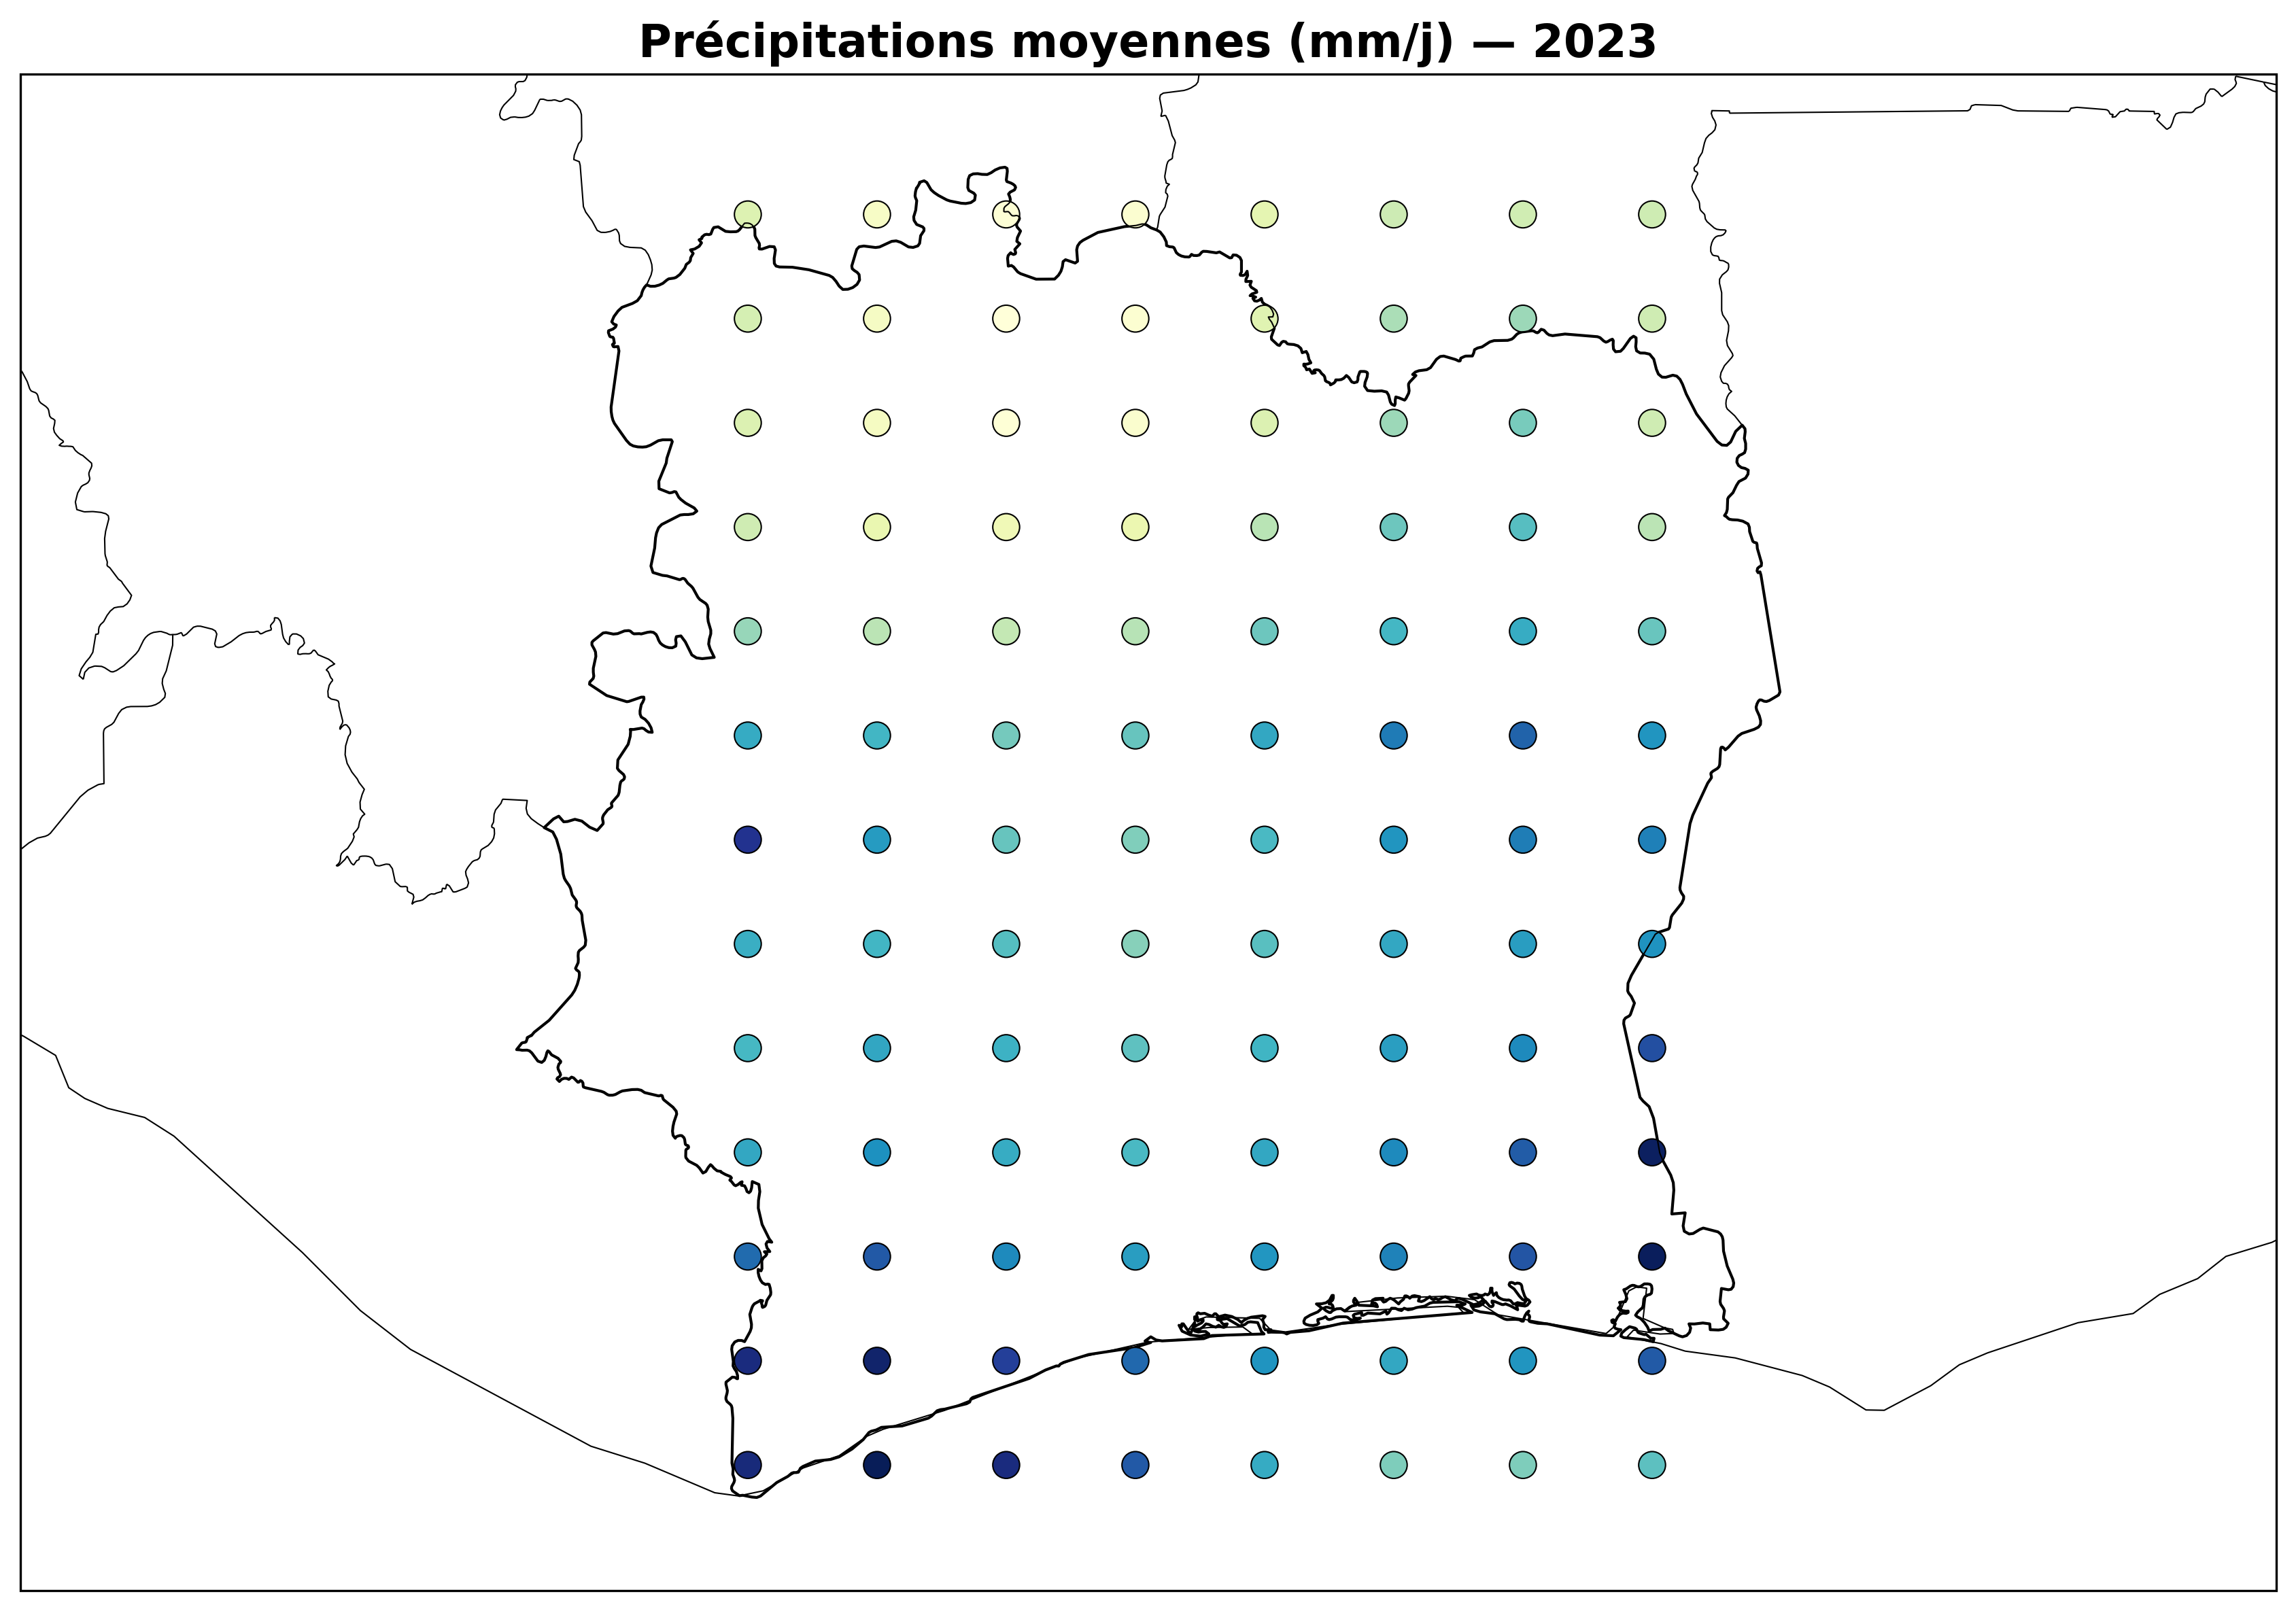

In [9]:
m = cp.Map(title="Précipitations moyennes (mm/j) — 2023")
m.add_polygons(civ, facecolor="none", edge_color="black", linewidth=1, alpha=1)
m.add_points(pts, column="PRECTOTCORR", cmap="YlGnBu", size=90)
m.show()